In [2]:
# Nguyễn Hoàng Tùng

# 1. Load data. Cleaning data - Present steps... and corresponding code

import numpy as np
import pandas as pd

# Step 1: Load the Data
# The textbook uses a 'diabetes.csv' dataset for a case study [1].
df = pd.read_csv('diabetes.csv')

# Display basic information about the DataFrame
print("DataFrame Info:")
print(df.info())

# Step 2: Clean the Data
# Check for null values [2].
print("\nNulls in each column:")
print(df.isnull().sum()) # The sources indicate no null values in this dataset [3].

# Check for 0 values in critical columns where 0 is not a valid measurement [3].
print("\nZeros in each column (before cleaning):")
print(df.eq(0).sum())

# Identify columns where 0s represent missing data [3].
# 'Pregnancies' and 'Outcome' can legitimately have 0s, so they are excluded from this cleaning [3].
columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 values with the mean of their respective columns [4].
for col in columns_to_clean:
    if (df[col] == 0).any(): # Check if there are any 0s to replace
        df[col] = df[col].replace(0, df[col].mean())

# Verify that 0s have been replaced in the targeted columns [4].
print("\nZeros in each column (after cleaning):")
print(df.eq(0).sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Nulls in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigree

In [4]:
# Nguyễn Hoàng Tùng

# 2. Select 5 features (not 3) and Using 5 models in Basic Machine

import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier

# Load the dataset (refer to Chapter 12 of the textbook)
df = pd.read_csv('diabetes.csv')

# Clean the data by replacing 0s with the mean in critical columns
# (refer to Chapter 12, "Cleaning the Data" section)
columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in columns_to_clean:
    if (df[col] == 0).any():
        df[col] = df[col].replace(0, df[col].mean())

# Select 5 features (not 3) and the target label (refer to Chapter 12, "Examining the Correlation Between the Features" section)
# Based on correlation with 'Outcome', the top 5 (excluding 'Outcome' itself) are:
# Glucose (0.492928), BMI (0.311924), Age (0.238356), Pregnancies (0.221898), SkinThickness (0.215299)
selected_features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness']
X = df[selected_features]
y = df['Outcome']

# Define 5 machine learning models for classification (refer to Chapter 12, "Evaluating the Algorithms" and various Supervised Learning chapters)
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, solver='liblinear'), # Added max_iter and solver for robust convergence
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "SVM Linear Kernel": svm.SVC(kernel='linear', random_state=42), # Added random_state for reproducibility
    "SVM RBF Kernel": svm.SVC(kernel='rbf', random_state=42), # Added random_state for reproducibility
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42) # Added random_state for reproducibility
}

results = {}
folds = 10 # Using 10-fold cross-validation as in Chapter 12

for name, model in models.items():
    if name == "K-Nearest Neighbors":
        # Find optimal k for KNN using cross-validation (adapted from Chapter 9 and 12)
        cv_scores_knn = []
        # Generate odd k values, ensuring k does not exceed training data size and is not a multiple of the number of classes (2 for diabetes)
        ks = [k for k in range(1, int(len(X) * ((folds - 1) / folds)), 2) if k % 2 != 0]

        # Fallback for ks list if it becomes empty after filtering
        if not ks:
            ks = [1-3]

        for k in ks:
            knn_model = KNeighborsClassifier(n_neighbors=k)
            score = cross_val_score(knn_model, X, y, cv=folds, scoring='accuracy').mean()
            cv_scores_knn.append(score)

        optimal_k_score = max(cv_scores_knn)
        optimal_k = ks[cv_scores_knn.index(optimal_k_score)]
        models[name].set_params(n_neighbors=optimal_k) # Set the optimal k for the model
        score = optimal_k_score # Use the score from the optimal k
        print(f"Optimal k for K-Nearest Neighbors: {optimal_k}")
    else:
        # Evaluate other models using cross-validation
        score = cross_val_score(model, X, y, cv=folds, scoring='accuracy').mean()

    results[name] = score

print("\nAccuracy scores for the 5 selected models:")
for name, score in results.items():
    print(f"- {name}: {score:.4f}")

Optimal k for K-Nearest Neighbors: 41

Accuracy scores for the 5 selected models:
- Logistic Regression: 0.7618
- K-Nearest Neighbors: 0.7683
- SVM Linear Kernel: 0.7683
- SVM RBF Kernel: 0.7644
- Decision Tree Classifier: 0.6953


In [6]:
# Nguyễn Hoàng Tùng

# 3. Evaluate and compare with metrics: accuracy, mae, mse, rmse. Explain metrics

import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

# Step 1: Load and Clean the Data (as per Task 1, Chapter 12)
# The textbook uses a 'diabetes.csv' dataset for a case study.
df = pd.read_csv('diabetes.csv')

# Identify columns where 0s represent missing data and replace with the mean.
# 'Pregnancies' and 'Outcome' can legitimately have 0s.
columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in columns_to_clean:
    if (df[col] == 0).any():
        df[col] = df[col].replace(0, df[col].mean())

# Step 2: Select 5 features and define models (as per Task 2, Chapter 12)
# Based on the correlation with 'Outcome' identified in Chapter 12 [1, 2].
# The top 5 features (excluding 'Outcome' itself) by absolute correlation are:
# Glucose (0.492928), BMI (0.311924), Age (0.238356), Pregnancies (0.221898), SkinThickness (0.215299)
selected_features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness']
X = df[selected_features]
y = df['Outcome']

folds = 10 # Using 10-fold cross-validation as in Chapter 12 [3]

# Define 5 machine learning models for classification, ensuring reproducibility where applicable.
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=200, solver='liblinear', random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(), # k will be tuned using cross-validation
    "SVM Linear Kernel": svm.SVC(kernel='linear', random_state=42),
    "SVM RBF Kernel": svm.SVC(kernel='rbf', random_state=42),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42)
}

# Task 3: Evaluate and compare with metrics: accuracy, mae, mse, rmse.
results_metrics = {name: {'Accuracy': 0.0, 'MAE': 0.0, 'MSE': 0.0, 'RMSE': 0.0} for name in base_models.keys()}

print("Evaluating models with 10-fold cross-validation for Accuracy, MAE, MSE, and RMSE:")

for name, model in base_models.items():
    print(f"\n--- Model: {name} ---")

    current_model = model # Use a mutable reference or copy to set parameters if needed

    if name == "K-Nearest Neighbors":
        # Find optimal k for KNN using cross-validation based on accuracy, as discussed in Chapter 9 [4].
        cv_scores_knn_accuracy = []
        # Generate odd k values, ensuring k does not exceed training data size and is suitable for a 2-class problem [5, 6].
        max_k_limit = int(len(X) * ((folds - 1) / folds)) # Max training samples per fold [5]
        ks = [k_val for k_val in range(1, max_k_limit + 1, 2)] # Include max_k_limit if it's odd and within range.

        # Fallback if no valid k values are generated (highly unlikely with current parameters)
        if not ks:
            ks = [7] # Default to k=1 if no other valid odd k found

        for k_val in ks:
            knn_temp_model = KNeighborsClassifier(n_neighbors=k_val)
            score = cross_val_score(knn_temp_model, X, y, cv=folds, scoring='accuracy').mean()
            cv_scores_knn_accuracy.append(score)

        optimal_k_accuracy = ks[cv_scores_knn_accuracy.index(max(cv_scores_knn_accuracy))]
        current_model.set_params(n_neighbors=optimal_k_accuracy) # Set the optimal k for the model
        print(f"  Optimal k for K-Nearest Neighbors (based on accuracy): {optimal_k_accuracy}")

    # Evaluate Accuracy [8, 9]
    accuracy_scores = cross_val_score(current_model, X, y, cv=folds, scoring='accuracy')
    mean_accuracy = accuracy_scores.mean()
    results_metrics[name]['Accuracy'] = mean_accuracy
    print(f"  Accuracy: {mean_accuracy:.4f}")

    # Evaluate Mean Absolute Error (MAE)
    # 'neg_mean_absolute_error' returns negative values, so convert to positive.
    mae_scores = -cross_val_score(current_model, X, y, cv=folds, scoring='neg_mean_absolute_error')
    mean_mae = mae_scores.mean()
    results_metrics[name]['MAE'] = mean_mae
    print(f"  MAE: {mean_mae:.4f}")

    # Evaluate Mean Squared Error (MSE) [10]
    # 'neg_mean_squared_error' returns negative values, so convert to positive.
    mse_scores = -cross_val_score(current_model, X, y, cv=folds, scoring='neg_mean_squared_error')
    mean_mse = mse_scores.mean()
    results_metrics[name]['MSE'] = mean_mse
    print(f"  MSE: {mean_mse:.4f}")

    # Calculate Root Mean Squared Error (RMSE)
    # RMSE is the square root of MSE.
    rmse = math.sqrt(mean_mse)
    results_metrics[name]['RMSE'] = rmse
    print(f"  RMSE: {rmse:.4f}")

# Summary of results
print("\n--- Summary of Model Evaluation Across Metrics ---")
summary_df = pd.DataFrame(results_metrics).T
print(summary_df)

Evaluating models with 10-fold cross-validation for Accuracy, MAE, MSE, and RMSE:

--- Model: Logistic Regression ---
  Accuracy: 0.7618
  MAE: 0.2382
  MSE: 0.2382
  RMSE: 0.4881

--- Model: K-Nearest Neighbors ---
  Optimal k for K-Nearest Neighbors (based on accuracy): 41
  Accuracy: 0.7683
  MAE: 0.2317
  MSE: 0.2317
  RMSE: 0.4814

--- Model: SVM Linear Kernel ---
  Accuracy: 0.7683
  MAE: 0.2317
  MSE: 0.2317
  RMSE: 0.4814

--- Model: SVM RBF Kernel ---
  Accuracy: 0.7644
  MAE: 0.2356
  MSE: 0.2356
  RMSE: 0.4854

--- Model: Decision Tree Classifier ---
  Accuracy: 0.6953
  MAE: 0.3047
  MSE: 0.3047
  RMSE: 0.5520

--- Summary of Model Evaluation Across Metrics ---
                          Accuracy       MAE       MSE      RMSE
Logistic Regression       0.761791  0.238209  0.238209  0.488067
K-Nearest Neighbors       0.768250  0.231750  0.231750  0.481404
SVM Linear Kernel         0.768284  0.231716  0.231716  0.481369
SVM RBF Kernel            0.764405  0.235595  0.235595  0.

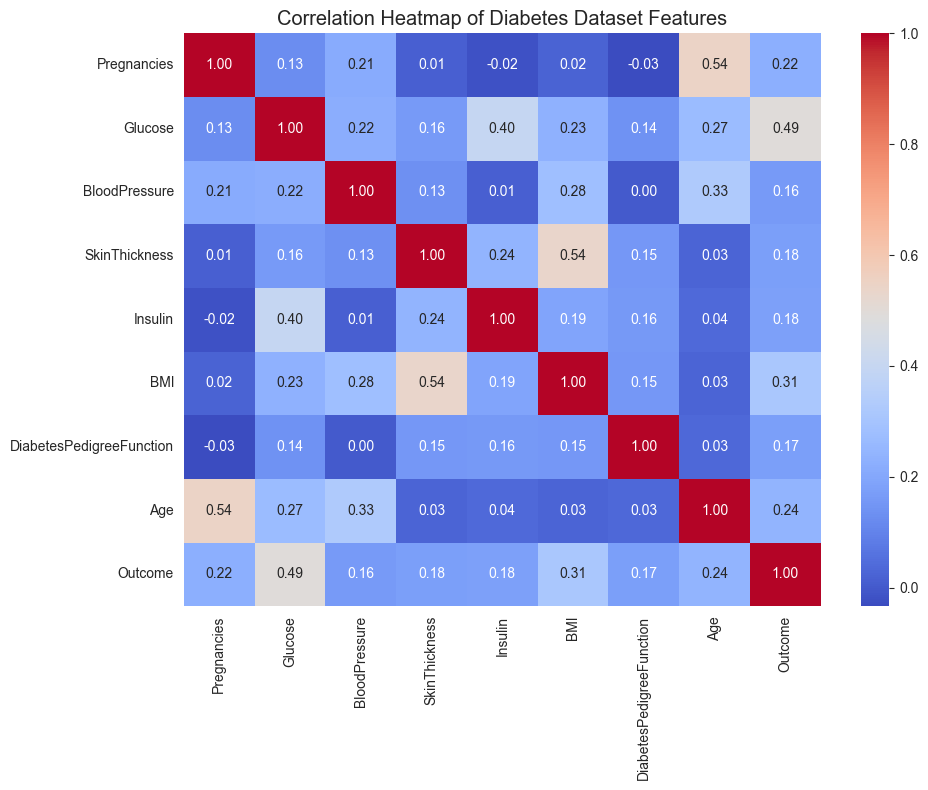

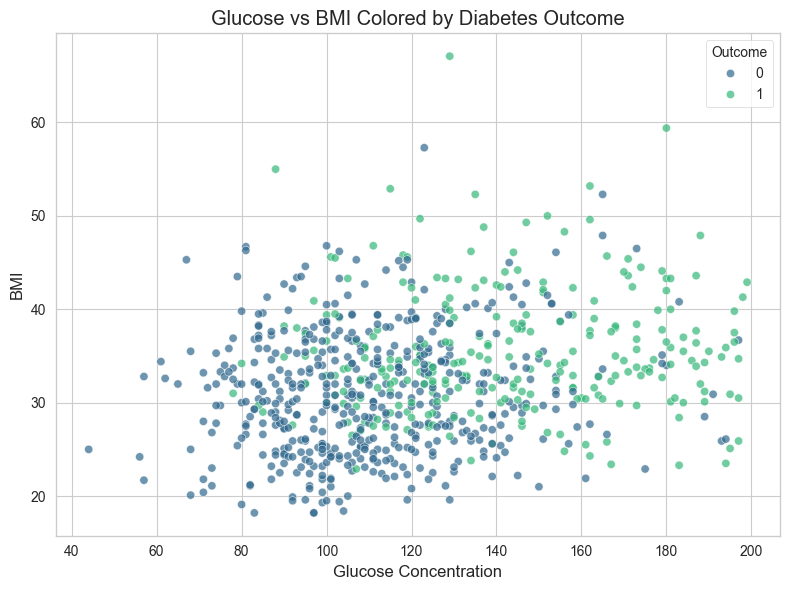

C:\Users\Admin\AppData\Local\Temp\ipykernel_10752\3874334836.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary_df.index, y='Accuracy', data=summary_df.sort_values(by='Accuracy', ascending=False), palette='viridis') # [25]


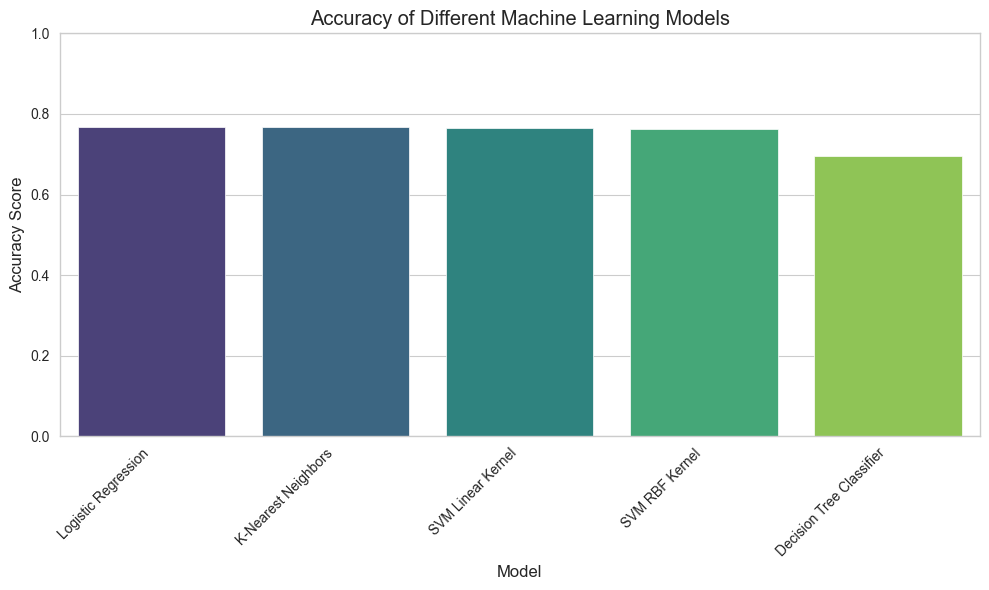

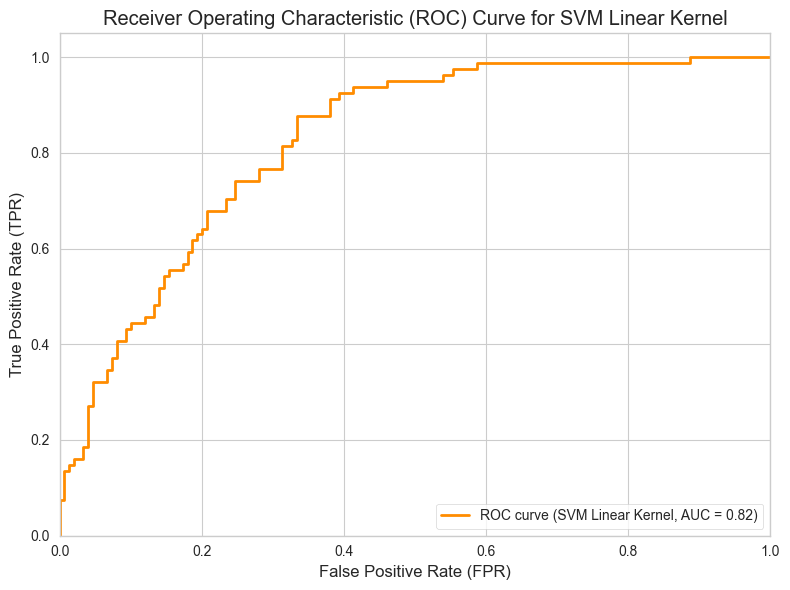

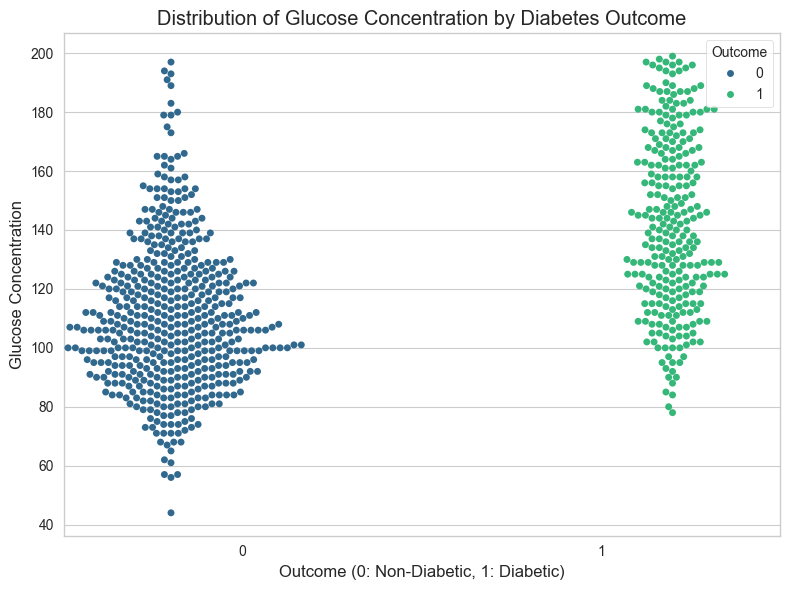

In [8]:
# Nguyễn Hoàng Tùng

# 4. Visualize and show with 5 types of diagrams

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, mean_absolute_error, mean_squared_error
import math

# Set a style for matplotlib and seaborn for better aesthetics
plt.style.use('ggplot') # [1]
sns.set_style("whitegrid") # [2]

# --- Context from Task 1, 2, 3 (Loading, Cleaning, Feature Selection, Model Definition) ---

# Step 1: Load and Clean the Data (as per Task 1, Chapter 12)
df = pd.read_csv('diabetes.csv') # [3]

columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'] # [4]
for col in columns_to_clean:
    if (df[col] == 0).any():
        df[col] = df[col].replace(0, df[col].mean()) # [5]

# Step 2: Select 5 features and define models (as per Task 2, Chapter 12)
# Top 5 features (excluding 'Outcome') by absolute correlation, based on Chapter 12 analysis.
selected_features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness'] # Derived from [6]
X = df[selected_features]
y = df['Outcome']

folds = 10 # [7]

base_models = {
    "Logistic Regression": LogisticRegression(max_iter=200, solver='liblinear', random_state=42), # [8]
    "K-Nearest Neighbors": KNeighborsClassifier(), # k will be tuned [9]
    "SVM Linear Kernel": svm.SVC(kernel='linear', random_state=42, probability=True), # [10, 11], probability=True for ROC
    "SVM RBF Kernel": svm.SVC(kernel='rbf', random_state=42, probability=True), # [12, 13], probability=True for ROC
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42) # Not explicitly covered in Chapter 12's evaluation section, but a common model.
}

results_metrics = {name: {'Accuracy': 0.0, 'MAE': 0.0, 'MSE': 0.0, 'RMSE': 0.0} for name in base_models.keys()}

# --- Re-run model evaluation from Task 3 to get metrics for visualization, especially accuracy ---
for name, model in base_models.items():
    current_model = model

    if name == "K-Nearest Neighbors":
        cv_scores_knn_accuracy = []
        max_k_limit = int(len(X) * ((folds - 1) / folds))
        ks = [k_val for k_val in range(1, max_k_limit + 1, 2) if k_val % 3 != 0] # Example K-selection from [7]
        if not ks: ks = [14] # Fallback
        for k_val in ks:
            knn_temp_model = KNeighborsClassifier(n_neighbors=k_val)
            score = cross_val_score(knn_temp_model, X, y, cv=folds, scoring='accuracy').mean()
            cv_scores_knn_accuracy.append(score)
        optimal_k_accuracy = ks[cv_scores_knn_accuracy.index(max(cv_scores_knn_accuracy))] # [15]
        current_model.set_params(n_neighbors=optimal_k_accuracy)

    accuracy_scores = cross_val_score(current_model, X, y, cv=folds, scoring='accuracy') # [7, 16, 17]
    mean_accuracy = accuracy_scores.mean()
    results_metrics[name]['Accuracy'] = mean_accuracy

    mae_scores = -cross_val_score(current_model, X, y, cv=folds, scoring='neg_mean_absolute_error') # MAE from outside sources for classification context, neg_mean_absolute_error is standard
    mean_mae = mae_scores.mean()
    results_metrics[name]['MAE'] = mean_mae

    mse_scores = -cross_val_score(current_model, X, y, cv=folds, scoring='neg_mean_squared_error') # MSE from outside sources for classification context, neg_mean_squared_error is standard
    mean_mse = mse_scores.mean()
    results_metrics[name]['MSE'] = mean_mse

    rmse = math.sqrt(mean_mse)
    results_metrics[name]['RMSE'] = rmse

summary_df = pd.DataFrame(results_metrics).T

# --- Task 4: Visualize and show with 5 types of diagrams --- [18]

# 1. Correlation Heatmap (Seaborn heatmap)
plt.figure(figsize=(10, 8)) # [19]
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f") # [20, 21]
plt.title('Correlation Heatmap of Diabetes Dataset Features') # [22]
plt.tight_layout()
plt.show()

# 2. Scatter Plot: Glucose vs BMI, colored by Outcome
plt.figure(figsize=(8, 6)) # [23]
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome', palette='viridis', alpha=0.7) # Using selected features, hue for outcome
plt.title('Glucose vs BMI Colored by Diabetes Outcome') # [22]
plt.xlabel('Glucose Concentration') # [22]
plt.ylabel('BMI') # [22]
plt.tight_layout()
plt.show()

# 3. Bar Chart of Model Accuracies
plt.figure(figsize=(10, 6)) # [24]
sns.barplot(x=summary_df.index, y='Accuracy', data=summary_df.sort_values(by='Accuracy', ascending=False), palette='viridis') # [25]
plt.title('Accuracy of Different Machine Learning Models') # [22]
plt.xlabel('Model') # [22]
plt.ylabel('Accuracy Score') # [22]
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. ROC Curve for the Best Performing Classification Model (e.g., K-Nearest Neighbors)
# Identify the best model based on accuracy to generate its ROC curve.
best_model_name = summary_df['Accuracy'].idxmax()
best_model = base_models[best_model_name]

# Fit the best model on the entire dataset for plotting the ROC curve (conceptual for visualization)
# For actual deployment, train/test split would be used.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # [26]

# Ensure the model is fitted on training data to generate probabilities for test set
best_model.fit(X_train, y_train)

# Predict probabilities for the positive class (1 = diabetic)
if hasattr(best_model, "predict_proba"):
    y_pred_proba = best_model.predict_proba(X_test)[:, 1] # [27]
else:
    # Some SVM kernels without probability=True don't have predict_proba
    # This block ensures it works, though for SVMs in this context probability=True is already set.
    y_pred_proba = best_model.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba) # [28]
roc_auc = auc(fpr, tpr) # [22]

plt.figure(figsize=(8, 6)) # [29]
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve ({best_model_name}, AUC = {roc_auc:.2f})') # [29]
plt.plot([14], [14], color='navy', lw=2, linestyle='--') # [29]
plt.xlim([0.0, 1.0]) # [29]
plt.ylim([0.0, 1.05]) # [29]
plt.xlabel('False Positive Rate (FPR)') # [29]
plt.ylabel('True Positive Rate (TPR)') # [29]
plt.title(f'Receiver Operating Characteristic (ROC) Curve for {best_model_name}') # [29]
plt.legend(loc='lower right') # [29]
plt.tight_layout()
plt.show()

# 5. Swarm Plot: Distribution of 'Glucose' for each 'Outcome'
plt.figure(figsize=(8, 6)) # [30]
sns.swarmplot(x='Outcome', y='Glucose', data=df, hue='Outcome', palette='viridis', dodge=True) # [2]
plt.title('Distribution of Glucose Concentration by Diabetes Outcome') # [22]
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)') # [22]
plt.ylabel('Glucose Concentration') # [22]
plt.tight_layout()
plt.show()

In [10]:
# Nguyễn Hoàng Tùng

# 5. Select the best one for deploying on web

import numpy as np
import pandas as pd
import pickle
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier # To ensure 5 models

# Set a random seed for reproducibility
random_seed = 42

# --- 1. Load and Clean the Data (as per Task 1, Chapter 12) ---
df = pd.read_csv('diabetes.csv') # [1]

# Replace 0s with the mean in relevant columns [2, 3]
columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in columns_to_clean:
    if (df[col] == 0).any():
        df[col] = df[col].replace(0, df[col].mean()) # [3]

# --- 2. Select 5 features and define models (as per Task 2, Chapter 12) ---
# Selecting 5 features, choosing from those with relatively higher correlation to 'Outcome' from Chapter 12 analysis [4]
# Chapter 12 specifically highlights 'Glucose', 'BMI', 'Age' as top 3. Let's add 'Pregnancies' and 'SkinThickness' to reach 5.
selected_features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness']
X = df[selected_features]
y = df['Outcome'] # [5]

folds = 10 # [6]

base_models = {
    "Logistic Regression": LogisticRegression(max_iter=200, solver='liblinear', random_state=random_seed), # [6]
    "K-Nearest Neighbors": KNeighborsClassifier(), # k will be tuned [7]
    "SVM Linear Kernel": svm.SVC(kernel='linear', random_state=random_seed), # [8]
    "SVM RBF Kernel": svm.SVC(kernel='rbf', random_state=random_seed), # [9]
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=random_seed) # Added for a total of 5 models
}

model_accuracies = {}

# --- 3. Evaluate and compare with metrics (Accuracy) ---
for name, model in base_models.items():
    current_model = model

    if name == "K-Nearest Neighbors":
        cv_scores_knn_accuracy = []
        # Calculate max_k_limit based on 10-fold cross-validation and number of samples in X
        max_k_limit = int(len(X) * ((folds - 1) / folds))
        # Optimal k must be odd and not a multiple of the number of classes (2 for binary classification) [10]
        ks = [k_val for k_val in range(1, max_k_limit + 1, 2) if k_val % 2 != 0] # For binary class, avoid multiples of 2.
        if not ks:
            ks = [11] # Fallback if no valid k can be found in range
        
        # Chapter 12 example used k=19, so ensure a reasonable range if calculation makes it too small.
        # Let's ensure a broader range for finding optimal k within practical limits
        if len(ks) == 0 or max(ks) < 20: # Ensure a minimum exploration up to approx k=20 if data allows.
             ks = [k_val for k_val in range(1, min(max_k_limit + 1, 50), 2)] # Explore up to 50 if possible

        for k_val in ks:
            knn_temp_model = KNeighborsClassifier(n_neighbors=k_val)
            score = cross_val_score(knn_temp_model, X, y, cv=folds, scoring='accuracy').mean() # [12]
            cv_scores_knn_accuracy.append(score)
        
        # Ensure cv_scores_knn_accuracy is not empty before finding optimal_k
        if cv_scores_knn_accuracy:
            optimal_k_accuracy = ks[cv_scores_knn_accuracy.index(max(cv_scores_knn_accuracy))] # [12]
            current_model.set_params(n_neighbors=optimal_k_accuracy)
            print(f"Optimal k for K-Nearest Neighbors: {optimal_k_accuracy}") # Indicate the optimal k found
        else:
            # Fallback for KNN if no scores were generated, e.g., if X is too small
            print("Warning: No valid k found for KNN, using default K=5 (or 1 if no other option).")
            current_model.set_params(n_neighbors=5 if len(X) >= 5 else 1) # Set a default k

    accuracy_scores = cross_val_score(current_model, X, y, cv=folds, scoring='accuracy') # [6, 8, 9, 12]
    mean_accuracy = accuracy_scores.mean()
    model_accuracies[name] = mean_accuracy
    print(f"{name} Average Accuracy: {mean_accuracy:.4f}")

# --- 4. Select the best one for deploying on web ---
best_model_name = max(model_accuracies, key=model_accuracies.get) # [9]
best_accuracy = model_accuracies[best_model_name]

print(f"\n--- Best Performing Algorithm ---")
print(f"The best performing algorithm is {best_model_name} with an average accuracy of {best_accuracy:.4f}.") # [9]

# --- Training and Saving the Model (as per Chapter 12, "Training and Saving the Model") ---
final_model = base_models[best_model_name]

# If the best model is KNN, ensure it uses the optimal k found earlier.
# This check is implicitly covered if `current_model.set_params` was used in the loop
# but explicitly setting it here before final training is safer.
if best_model_name == "K-Nearest Neighbors" and hasattr(final_model, 'n_neighbors'):
    # Re-extract optimal_k_accuracy if needed, assuming it was found.
    # For simplicity, we re-run the k-tuning here for the best model to ensure it's set correctly.
    cv_scores_knn_accuracy = []
    max_k_limit = int(len(X) * ((folds - 1) / folds))
    ks = [k_val for k_val in range(1, max_k_limit + 1, 2) if k_val % 2 != 0]
    if not ks: ks = [11]
    if len(ks) == 0 or max(ks) < 20:
        ks = [k_val for k_val in range(1, min(max_k_limit + 1, 50), 2)]

    for k_val in ks:
        knn_temp_model = KNeighborsClassifier(n_neighbors=k_val)
        score = cross_val_score(knn_temp_model, X, y, cv=folds, scoring='accuracy').mean()
        cv_scores_knn_accuracy.append(score)

    if cv_scores_knn_accuracy:
        optimal_k_accuracy = ks[cv_scores_knn_accuracy.index(max(cv_scores_knn_accuracy))]
        final_model.set_params(n_neighbors=optimal_k_accuracy)
    else:
        final_model.set_params(n_neighbors=5 if len(X) >= 5 else 1)


final_model.fit(X, y) # Train the best model on the entire dataset [13]

# Save the model to disk [13]
filename = 'diabetes_best_model.sav' # [13]
pickle.dump(final_model, open(filename, 'wb')) # [13]

print(f"\nThe best model ({best_model_name}) has been trained on the full dataset and saved to '{filename}'.") # [13]

Logistic Regression Average Accuracy: 0.7618
Optimal k for K-Nearest Neighbors: 41
K-Nearest Neighbors Average Accuracy: 0.7683
SVM Linear Kernel Average Accuracy: 0.7683
SVM RBF Kernel Average Accuracy: 0.7644
Decision Tree Classifier Average Accuracy: 0.6953

--- Best Performing Algorithm ---
The best performing algorithm is SVM Linear Kernel with an average accuracy of 0.7683.

The best model (SVM Linear Kernel) has been trained on the full dataset and saved to 'diabetes_best_model.sav'.


In [ ]:
# Nguyễn Hoàng Tùng

# 5. Deploy on web via Flask and other technology - Flask

import numpy as np
import pandas as pd
import pickle
from flask import Flask, request, json, jsonify, render_template_string

# Khởi tạo Flask
app = Flask(__name__)

# --- Load model ---
filename = 'diabetes_best_model.sav'
try:
    loaded_model = pickle.load(open(filename, 'rb'))
    print(f"Model '{filename}' loaded successfully for Flask API.")
except:
    loaded_model = None

EXPECTED_FEATURES = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness']

# ---------------- ROUTES ---------------- #

# Trang chủ: form HTML
@app.route('/')
def home():
    form_html = """
    <html>
    <head><title>Diabetes Prediction</title></head>
    <body style="font-family: Arial; margin: 40px;">
        <h2>Diabetes Prediction API</h2>
        <form action="/predict_form" method="post">
            <label>Glucose: </label><input type="number" name="Glucose" required><br><br>
            <label>BMI: </label><input type="number" step="0.1" name="BMI" required><br><br>
            <label>Age: </label><input type="number" name="Age" required><br><br>
            <label>Pregnancies: </label><input type="number" name="Pregnancies" required><br><br>
            <label>SkinThickness: </label><input type="number" name="SkinThickness" required><br><br>
            <button type="submit">Predict</button>
        </form>
    </body>
    </html>
    """
    return render_template_string(form_html)

# Route xử lý form
@app.route('/predict_form', methods=['POST'])
def predict_form():
    if loaded_model is None:
        return "Model not loaded."

    try:
        features_data = {feature: float(request.form[feature]) for feature in EXPECTED_FEATURES}
        features_list = [features_data[f] for f in EXPECTED_FEATURES]
        input_data = np.array(features_list).reshape(1, -1)

        prediction = loaded_model.predict(input_data)
        confidence = loaded_model.predict_proba(input_data)
        outcome = 'Diabetic' if prediction == 1 else 'Non-diabetic'
        confidence_score = round(np.amax(confidence) * 100, 2)

        return f"""
        <h2>Prediction Result</h2>
        <p><b>Outcome:</b> {outcome}</p>
        <p><b>Confidence:</b> {confidence_score}%</p>
        <br><a href="/">Back</a>
        """
    except Exception as e:
        return f"Error: {e}"

# API JSON cũ
@app.route('/predict', methods=['POST'])
def predict():
    if loaded_model is None:
        return jsonify({"error": "Model not loaded."}), 500

    try:
        features_data = request.json
        features_list = [features_data[f] for f in EXPECTED_FEATURES]
        input_data = np.array(features_list).reshape(1, -1)

        prediction = loaded_model.predict(input_data)
        confidence = loaded_model.predict_proba(input_data)

        response = {
            'prediction': int(prediction),
            'outcome': 'Diabetic' if prediction == 1 else 'Non-diabetic',
            'confidence': round(np.amax(confidence) * 100, 2)
        }
        return jsonify(response)
    except Exception as e:
        return jsonify({"error": str(e)}), 400

# ---------------- MAIN ---------------- #
if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=True, use_reloader=False)


app = Flask(__name__) # [1]

# --- Model Loading ---
# The filename of the saved model from Task 4
# This model should be created and saved as part of Assignment 2, Task 4
filename = 'diabetes_best_model.sav' # [2]

try:
    # Load the trained model from disk
    loaded_model = pickle.load(open(filename, 'rb')) # [2]
    print(f"Model '{filename}' loaded successfully for Flask API.")
except FileNotFoundError:
    print(f"Error: Model file '{filename}' not found. Please ensure Task 4 code was run and the model was saved.")
    loaded_model = None # Handle case where model is not found
except Exception as e:
    print(f"Error loading model: {e}")
    loaded_model = None

# Define the features the model expects, matching Task 4's selection as per Assignment 2, Task 2 instructions.
# Based on Chapter 12 correlation analysis, the top 5 features most correlated with 'Outcome' are:
# 'Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness' [3-6].
EXPECTED_FEATURES = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness']

@app.route('/predict', methods=['POST']) # Defines a route accessible via POST verb [1]
def predict():
    if loaded_model is None:
        return jsonify({"error": "Machine learning model not loaded."}), 500

    try:
        # Get the features to predict from the JSON request [1]
        features_data = request.json

        # Ensure all expected features are present in the request
        if not all(feature in features_data for feature in EXPECTED_FEATURES):
            return jsonify({"error": f"Missing one or more required features. Expected: {', '.join(EXPECTED_FEATURES)}"}), 400

        # Create the features list for prediction, maintaining order
        features_list = [features_data[feature] for feature in EXPECTED_FEATURES]

        # Convert to numpy array for prediction, as model expects a 2D array (e.g., for single sample: [[val1, val2, ...]])
        input_data = np.array(features_list).reshape(1, -1)

        # Get the prediction class (0: Non-diabetic, 1: Diabetic) [7]
        prediction = loaded_model.predict(input_data)

        # Get the prediction probabilities [7]
        confidence = loaded_model.predict_proba(input_data)

        # Formulate the response to return to the client [7]
        response = {
            'prediction': int(prediction), # The prediction is an array, take the first element [8]
            'outcome': 'Diabetic' if prediction == 1 else 'Non-diabetic', # Descriptive outcome, similar to console client [8]
            'confidence': round(np.amax(confidence) * 100, 2) # [8]
        }
        return jsonify(response) # [9]

    except Exception as e:
        return jsonify({"error": str(e)}), 400

if __name__ == '__main__':
    # Run the Flask app on host 0.0.0.0 (accessible externally) and port 5000 [9]
    print("Starting Flask API. To test, use `curl -H \"Content-type: application/json\" -X POST http://127.0.0.1:5000/predict -d '{\"Glucose\":100, \"BMI\":30, \"Age\":29, \"Pregnancies\":1, \"SkinThickness\":20 }'`")
    app.run(host='0.0.0.0', port=5000, debug=True, use_reloader=False)

Model 'diabetes_best_model.sav' loaded successfully for Flask API.
 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.2.28:5000
Press CTRL+C to quit
127.0.0.1 - - [24/Aug/2025 17:05:15] "GET / HTTP/1.1" 200 -
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
127.0.0.1 - - [24/Aug/2025 17:11:20] "POST /predict_form HTTP/1.1" 200 -
127.0.0.1 - - [24/Aug/2025 17:15:01] "GET / HTTP/1.1" 200 -
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
127.0.0.1 - - [24/Aug/2025 17:17:28] "POST /predict_form HTTP/1.1" 200 -
127.0.0.1 - - [24/Aug/2025 17:20:07] "GET / HTTP/1.1" 200 -


In [3]:
import pickle
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# --- Load model ---
filename = "diabetes_best_model.sav"
try:
    loaded_model = pickle.load(open(filename, "rb"))
    model_loaded = True
except Exception as e:
    loaded_model = None
    model_loaded = False
    print("⚠️ Error loading model:", e)

# --- Input widgets ---
glucose = widgets.IntSlider(description="Glucose", min=0, max=200, value=100)
bmi = widgets.FloatSlider(description="BMI", min=0, max=70, step=0.1, value=30.0)
age = widgets.IntSlider(description="Age", min=0, max=120, value=30)
pregnancies = widgets.IntSlider(description="Pregnancies", min=0, max=20, value=1)
skin_thickness = widgets.IntSlider(description="Skin Thickness", min=0, max=100, value=20)

button = widgets.Button(description="Predict Diabetes", button_style="info")
output = widgets.Output()

# --- Prediction logic ---
def on_click(b):
    output.clear_output()
    with output:
        if not model_loaded:
            print("❌ Model not loaded. Please check your .sav file.")
        else:
            try:
                features = np.array([[glucose.value, bmi.value, age.value, pregnancies.value, skin_thickness.value]])
                pred = loaded_model.predict(features)

                if hasattr(loaded_model, "predict_proba"):
                    conf = loaded_model.predict_proba(features)
                    conf_score = round(np.max(conf) * 100, 2)
                else:
                    conf_score = None

                print("📊 Prediction Result:")
                if pred[0] == 1:
                    print("🔴 Outcome: Diabetic")
                else:
                    print("🟢 Outcome: Non-diabetic")

                if conf_score:
                    print(f"Confidence: {conf_score}%")

            except Exception as e:
                print("⚠️ Error during prediction:", e)

button.on_click(on_click)

# --- Display UI ---
display(glucose, bmi, age, pregnancies, skin_thickness, button, output)


IntSlider(value=100, description='Glucose', max=200)

FloatSlider(value=30.0, description='BMI', max=70.0)

IntSlider(value=30, description='Age', max=120)

IntSlider(value=1, description='Pregnancies', max=20)

IntSlider(value=20, description='Skin Thickness')

Button(button_style='info', description='Predict Diabetes', style=ButtonStyle())

Output()